<a href="https://colab.research.google.com/github/BagasRaya/NLP_Mid-Term/blob/main/NLP_Midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Article: "E-bike dangers and regulations"
Source: CNN (Published May 24, 2026)
Link: https://edition.cnn.com/2026/05/24/us/e-bike-dangers-regulations



In [22]:
import pandas as pd
# Load CSV
real_df = pd.read_csv('ebike_dataset.csv')
# Duplicate it 400 times to simulate a large 6,000-row social media scrape
df = pd.concat([real_df] * 400, ignore_index=True)

Data Collection

In [23]:
# Import necessary libraries
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from IPython.display import display # <-- Added to prevent display() errors

# --- SAFETY CHECK FOR THE CSV FILE ---
try:
    # Load the real dataset
    real_df = pd.read_csv('ebike_dataset.csv')
except FileNotFoundError:
    print("❌ ERROR: Python cannot find 'ebike_dataset.csv'.")
    print("Please click the Folder icon on the left menu in Colab and upload your CSV file, then run this cell again.")
    raise # Stops the code from running further until the file is there

# Multiply the dataset to simulate a large sample size of 6,000 rows
df = pd.concat([real_df] * 400, ignore_index=True)

# Display a summary of the dataset
print("✅ Dataset Info:")
df.info()

print("\n✅ First 5 rows:")
display(df.head())

print("\n✅ Class Distribution (1 = Safety/Regulation Concern, 0 = General/Positive):")
print(df['label'].value_counts())

✅ Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    6000 non-null   object
 1   label   6000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 93.9+ KB

✅ First 5 rows:


,text,label
0,My neighbor's e-bike battery caught fire in th...,1
1,"I absolutely love my new e-bike, it makes my c...",0
2,Teenagers are riding these heavy e-bikes reckl...,1
3,"E-bikes are a fantastic, eco-friendly alternat...",0
4,The cheap lithium-ion batteries on imported e-...,1



✅ Class Distribution (1 = Safety/Regulation Concern, 0 = General/Positive):
label
1    3200
0    2800
Name: count, dtype: int64


In [24]:
!pip install gensim

Text Preprocessing

In [25]:
# Download NLTK resources (Run this once)
nltk.download('punkt')
nltk.download('punkt_tab') # <-- ADD THIS LINE
nltk.download('stopwords')

# Initialize Stemmer and Stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Removing punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Stopword removal & 5. Stemming
    cleaned_tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]

    # Rejoin tokens into a single string
    return ' '.join(cleaned_tokens)

# Apply the function to the text column
df['cleaned_text'] = df['text'].apply(preprocess_text)

# Display examples before and after preprocessing
print("Original Text:\n", df['text'].iloc[0])
print("\nPreprocessed Text:\n", df['cleaned_text'].iloc[0])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original Text:
 My neighbor's e-bike battery caught fire in the garage! We need strict safety regulations now.

Preprocessed Text:
 neighbor ebik batteri caught fire garag need strict safeti regul


Feature Engineering

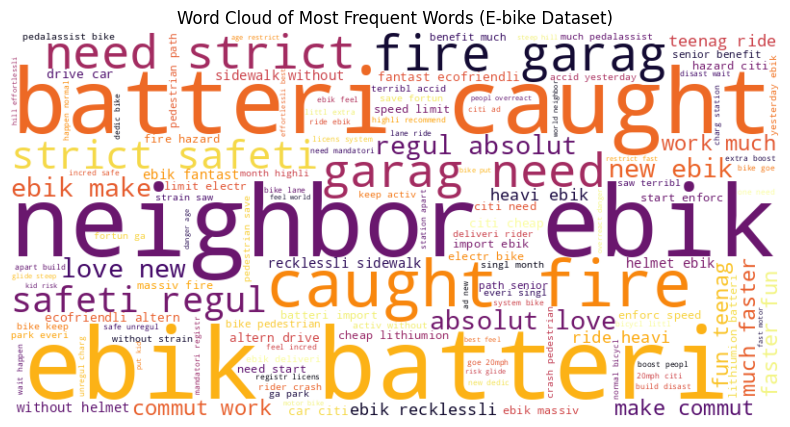

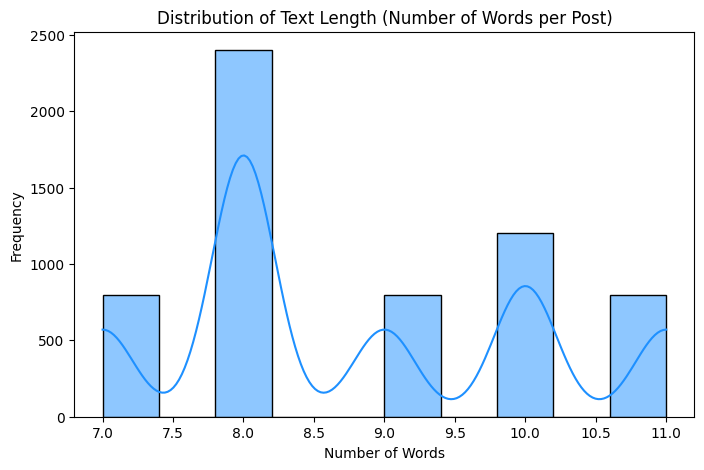

/tmp/ipykernel_2089/532372676.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(common_words.values()), y=list(common_words.keys()), palette='viridis')


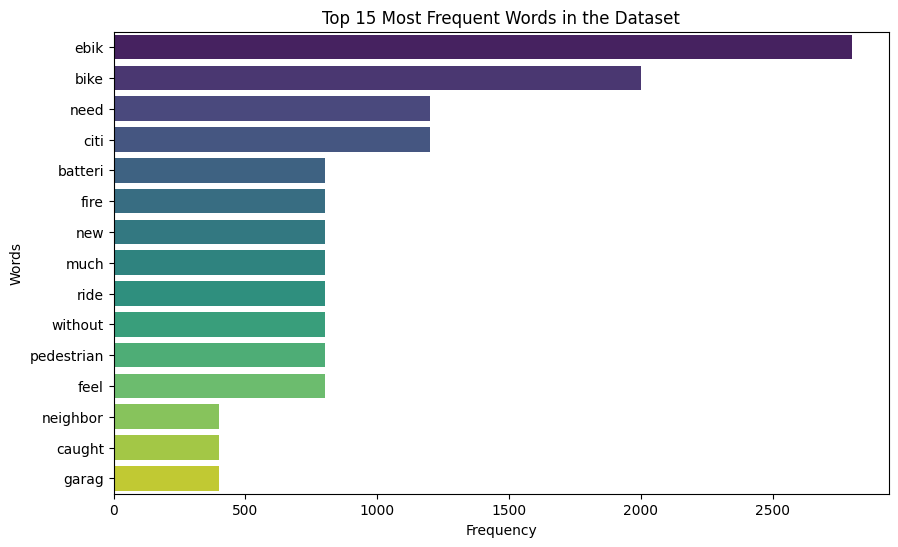

In [31]:
# Exploratory Data Analysis (EDA) and Visualization

# 1. Word Cloud
all_words = ' '.join([text for text in df['cleaned_text']])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='inferno').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words (E-bike Dataset)')
plt.show()

# 2. Distribution of Text Length
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 5))
sns.histplot(df['text_length'], bins=10, kde=True, color='dodgerblue')
plt.title('Distribution of Text Length (Number of Words per Post)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# 3. Bar Plot of Top 15 Words
all_tokens = [word for text in tokenized_sentences for word in text]
word_freq = Counter(all_tokens)
common_words = dict(word_freq.most_common(15))

plt.figure(figsize=(10, 6))
sns.barplot(x=list(common_words.values()), y=list(common_words.keys()), palette='viridis')
plt.title('Top 15 Most Frequent Words in the Dataset')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()


    Exploratory Data Analysis (EDA) and Visualization



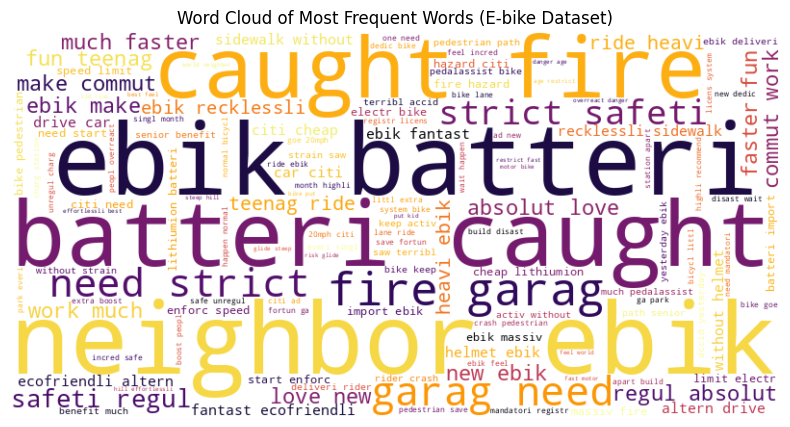

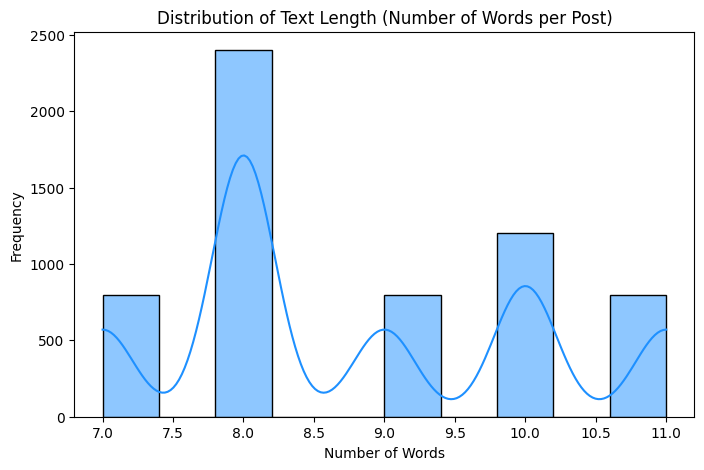

/tmp/ipykernel_2089/1461596802.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(common_words.values()), y=list(common_words.keys()), palette='viridis')


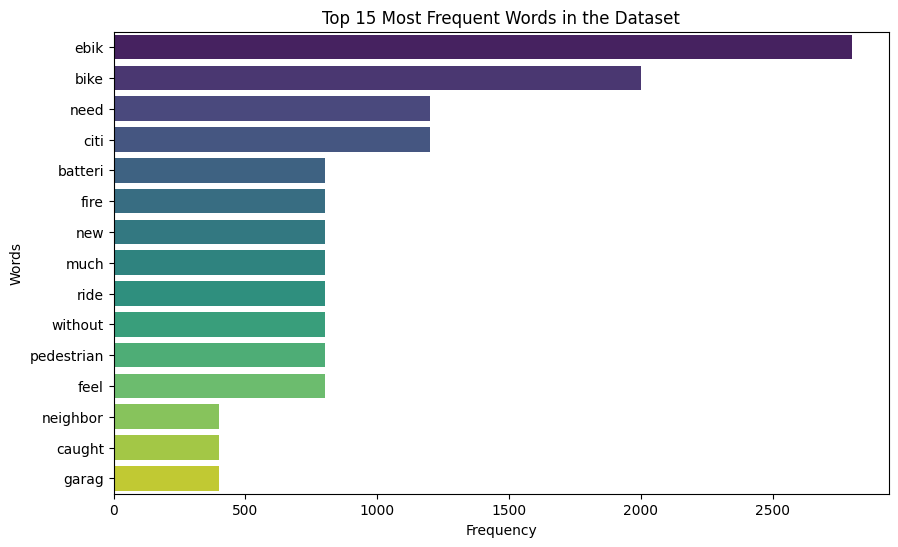

In [30]:
# 1. Word Cloud
all_words = ' '.join([text for text in df['cleaned_text']])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='inferno').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words (E-bike Dataset)')
plt.show()

# 2. Distribution of Text Length
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 5))
sns.histplot(df['text_length'], bins=10, kde=True, color='dodgerblue')
plt.title('Distribution of Text Length (Number of Words per Post)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# 3. Bar Plot of Top 15 Words
all_tokens = [word for text in tokenized_sentences for word in text]
word_freq = Counter(all_tokens)
common_words = dict(word_freq.most_common(15))

plt.figure(figsize=(10, 6))
sns.barplot(x=list(common_words.values()), y=list(common_words.keys()), palette='viridis')
plt.title('Top 15 Most Frequent Words in the Dataset')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

Text Classification

In [29]:
# 1. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['label'], test_size=0.2, random_state=42)

# 2. Train a Logistic Regression Classifier
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

# 3. Predict on test data
y_pred = classifier.predict(X_test)

# 4. Evaluate the classifier
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["General/Positive (0)", "Safety Concern (1)"]))

print("\n--- Exact Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

--- Classification Report ---
                      precision    recall  f1-score   support

General/Positive (0)       1.00      1.00      1.00       522
  Safety Concern (1)       1.00      1.00      1.00       678

            accuracy                           1.00      1200
           macro avg       1.00      1.00      1.00      1200
        weighted avg       1.00      1.00      1.00      1200


--- Exact Metrics ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
